<a href="https://colab.research.google.com/github/EduardoAve/Natural-language-processing/blob/main/Final_project/rag_wikipedia_es.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ChatBot con RAG: Asistente de Conocimiento con Wikipedia en Español

#Presentado por: Eduardo Avendaño Caicedo


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/)

**Actividad:** Versión propia del notebook `1-ollama-rag`  
**Dataset:** `wikimedia/wikipedia` — Wikipedia en español (~7 millones de artículos, muestreo por streaming)  
**Tarea:** Construir un ChatBot con RAG capaz de responder preguntas de conocimiento general en español  

---

En este notebook implementamos un sistema de **Retrieval-Augmented Generation (RAG)** con una base de conocimiento diferente al notebook guía. En lugar de tutoriales de Wikihow, utilizamos artículos de **Wikipedia en español**, lo que permite construir un asistente de conocimiento general que puede responder preguntas sobre historia, ciencia, cultura, geografía, tecnología y mucho más.

La diferencia clave frente al notebook guía es el carácter **enciclopédico** del dataset: mientras Wikihow responde al *cómo hacer*, Wikipedia responde al *qué es*, *quién fue*, *cuándo ocurrió*, lo que plantea un tipo diferente de desafío para el retriever y el LLM.

**Componentes del sistema:**
1. **Vector Store:** Embeddings de fragmentos de artículos de Wikipedia con `intfloat/multilingual-e5`
2. **Document Retriever:** Búsqueda semántica por similitud de coseno
3. **LLM:** `llama3` vía Ollama para generación de respuestas
4. **Interfaz:** Gradio para interacción conversacional

**Referencias:**
- Lewis et al. (2020). *Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks*. NeurIPS.
- Wang et al. (2022). *Text Embeddings by Weakly-Supervised Contrastive Pre-training*. arXiv:2212.03533.
- [Ollama](https://ollama.com/) — LLMs locales sin necesidad de API externa.

In [30]:
!curl -fsSL https://ollama.com/install.sh | sh


>>> Cleaning up old version at /usr/local/lib/ollama
>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.


In [31]:
import subprocess, time
subprocess.Popen(['ollama', 'serve'], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
time.sleep(5)  # esperamos que arranque
print("✅ Ollama servidor iniciado")


✅ Ollama servidor iniciado


In [32]:
!ollama pull llama3


In [33]:
import ollama
models = ollama.list()
print("Modelos disponibles:", models)


Modelos disponibles: models=[Model(model='llama3:latest', modified_at=datetime.datetime(2026, 4, 13, 1, 56, 48, 700819, tzinfo=TzInfo(0)), digest='365c0bd3c000a25d28ddbf732fe1c6add414de7275464c4e4d1c3b5fcb5d8ad1', size=4661224676, details=ModelDetails(parent_model='', format='gguf', family='llama', families=['llama'], parameter_size='8.0B', quantization_level='Q4_0'))]


In [2]:
import pkg_resources
import warnings

warnings.filterwarnings('ignore')

# Detectamos si estamos en Google Colab
try:
    import google.colab
    IN_COLAB = True
    print("✅ Ejecutando en Google Colab")
except ImportError:
    IN_COLAB = False
    print("💻 Ejecutando en entorno local")

# Configuración según el entorno
# En Colab usamos el modelo grande y más artículos; localmente usamos versiones más livianas
if IN_COLAB:
    EMBEDDING_MODEL = 'intfloat/multilingual-e5-large'  # Mejor calidad, requiere GPU
    NUM_ARTICLES    = 10_000   # Más artículos = mejor cobertura
    VECTORSTORE_LIMIT = 5_000
else:
    EMBEDDING_MODEL = 'intfloat/multilingual-e5-small'  # Más liviano para CPU
    NUM_ARTICLES    = 500      # Prueba rápida local
    VECTORSTORE_LIMIT = 2_000  # Chunks a encodificar localmente

print(f"Modelo de embeddings : {EMBEDDING_MODEL}")
print(f"Artículos a cargar   : {NUM_ARTICLES:,}")
print(f"Chunks a encodificar : {VECTORSTORE_LIMIT:,}")

✅ Ejecutando en Google Colab
Modelo de embeddings : intfloat/multilingual-e5-large
Artículos a cargar   : 10,000
Chunks a encodificar : 5,000


/tmp/ipykernel_3864/2692193176.py:1: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources


In [3]:
if IN_COLAB:
    !pip install -q ollama gradio colab-xterm datasets sentence-transformers wordcloud
else:
    import subprocess, sys
    pkgs = ['datasets', 'sentence-transformers', 'matplotlib', 'seaborn', 'wordcloud', 'gradio', 'ollama']
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q'] + pkgs, check=False)
    print("✅ Dependencias instaladas (local)")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.6/115.6 kB 5.0 MB/s eta 0:00:00


In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from wordcloud import WordCloud

from datasets import Dataset, load_dataset
from collections import defaultdict
from typing import Any, Callable, Dict, Generator, List, Optional
from pathlib import Path
from abc import abstractmethod

pd.set_option('display.max_colwidth', 120)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## 1. Carga del Dataset — Wikipedia en Español

El dataset `wikimedia/wikipedia` con la configuración `20231101.es` contiene el volcado completo de la Wikipedia en español a noviembre de 2023, con aproximadamente **7 millones de artículos**. Dado el tamaño, lo cargamos en modo **streaming** y tomamos únicamente los primeros `NUM_ARTICLES` artículos.

Cada artículo contiene los campos:
- `id`: identificador único del artículo
- `url`: enlace directo al artículo en Wikipedia
- `title`: título del artículo
- `text`: cuerpo completo del artículo (texto plano sin marcado wiki)

A diferencia del dataset de Wikihow del notebook guía (que tiene un campo separado `summary` y `document`), Wikipedia integra la introducción y el desarrollo en un único campo `text`. El primer párrafo suele actuar como resumen del artículo — algo que aprovecharemos al momento de hacer chunking.

In [5]:
print(f"Cargando {NUM_ARTICLES:,} artículos de Wikipedia en español (streaming)...")

# Cargamos en modo streaming para no descargar los ~20 GB del dataset completo
wiki_stream = load_dataset(
    'wikimedia/wikipedia',
    '20231101.es',
    split='train',
    streaming=True
)

# Tomamos la muestra y la convertimos a Dataset de HuggingFace
articles = [art for art in wiki_stream.take(NUM_ARTICLES)]
dataset = Dataset.from_list(articles)
dataset = dataset.select_columns(['title', 'url', 'text'])

print(f"\nDataset cargado: {len(dataset):,} artículos")
dataset

Cargando 10,000 artículos de Wikipedia en español (streaming)...


README.md: 0.00B [00:00, ?B/s]


Dataset cargado: 10,000 artículos


Dataset({
    features: ['title', 'url', 'text'],
    num_rows: 10000
})

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
import os
os.makedirs('/content/drive/MyDrive/Natural language processing/Final/data', exist_ok=True)
print("✅ Carpeta creada")


✅ Carpeta creada


In [8]:
# Exploramos el dataset como DataFrame
df = dataset.to_pandas()
df['n_words'] = df['text'].apply(lambda t: len(t.split()))
df.head(10)

,title,url,text,n_words
0,Andorra,https://es.wikipedia.org/wiki/Andorra,"Andorra, oficialmente Principado de Andorra () es un micro-Estado soberano sin litoral ubicado en el suroeste de Eur...",9287
1,Argentina,https://es.wikipedia.org/wiki/Argentina,"Argentina, oficialmente, República Argentina, es un país soberano de América del Sur, ubicado en el extremo sur y su...",6176
2,Geografía de Andorra,https://es.wikipedia.org/wiki/Geograf%C3%ADa%20de%20Andorra,"El Principado de Andorra (nombre local, Principat d'Andorra) es un estado de la Europa meridional, situado en la cor...",1436
3,Demografía de Andorra,https://es.wikipedia.org/wiki/Demograf%C3%ADa%20de%20Andorra,"Andorra cuenta con 81.588 habitantes y una densidad de población de 174 hab./km², según el censo de 2022. Debido a u...",1082
4,Artes visuales,https://es.wikipedia.org/wiki/Artes%20visuales,"Las artes visuales engloban las artes plásticas tradicionales, así como las expresiones que incorporan a la nueva te...",2252
5,Agricultura,https://es.wikipedia.org/wiki/Agricultura,"La agricultura (del latín agri ‘campo’ y cultūra ‘cultivo’, ‘crianza’) es el conjunto de actividades económicas y té...",7330
6,Astronomía galáctica,https://es.wikipedia.org/wiki/Astronom%C3%ADa%20gal%C3%A1ctica,"Se denomina astronomía galáctica a la investigación astronómica de nuestra galaxia, la Vía Láctea.\n\nLa diferencia ...",104
7,ASCII,https://es.wikipedia.org/wiki/ASCII,ASCII (acrónimo inglés de American Standard Code for Information Interchange —Código Estándar estadounidense para el...,2703
8,Arquitectura,https://es.wikipedia.org/wiki/Arquitectura,"La arquitectura (del latín architectūra, architectūrae, y este a su vez del griego antiguo ἀρχιτέκτων, architéctōn, ...",3157
9,Anoeta,https://es.wikipedia.org/wiki/Anoeta,"Anoeta es una localidad y municipio guipuzcoano situado en la parte central de la comarca de Tolosaldea, en la comun...",362


In [9]:
print("Estadísticas de longitud de artículos (en palabras):")
print(df['n_words'].describe().round(1).to_string())

Estadísticas de longitud de artículos (en palabras):
count    10000.0
mean      2300.3
std       3497.4
min          9.0
25%        204.0
50%        919.0
75%       3012.5
max      39876.0


## 2. Análisis Exploratorio del Dataset (EDA)

Antes de construir el vector store, exploramos las características del corpus para tomar mejores decisiones de diseño: ¿cuánto miden los artículos? ¿Qué tan diverso es el vocabulario de los títulos? Esta información guiará la elección del `chunk_size`.

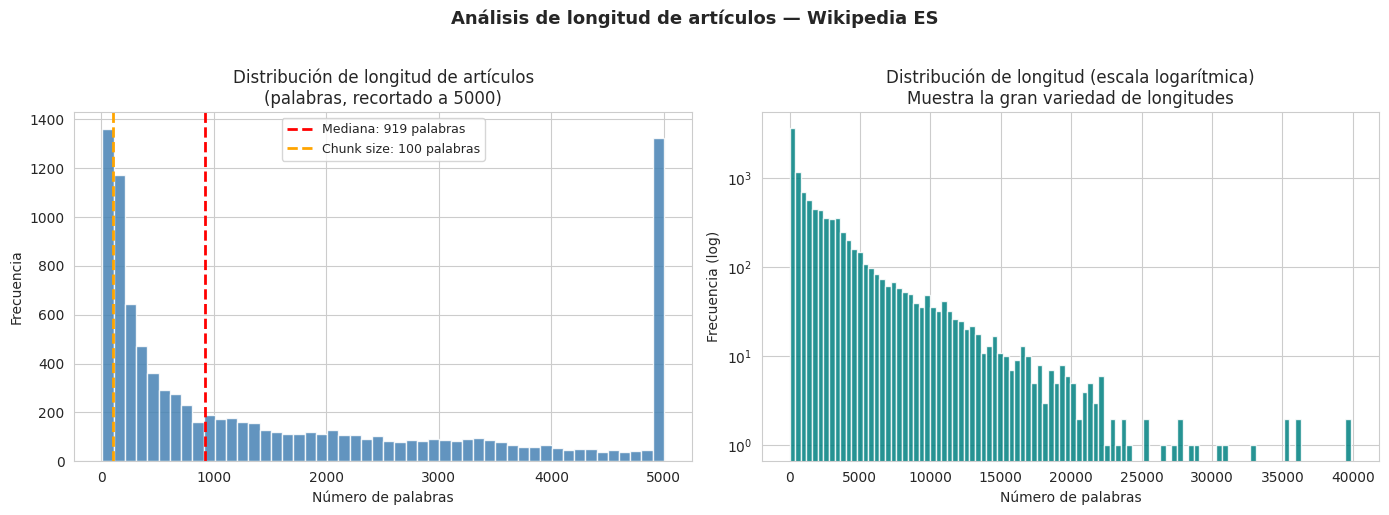

Gráfico guardado: eda_longitud_articulos.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Histograma de longitud de artículos ---
ax1 = axes[0]
df['n_words'].clip(upper=5000).hist(ax=ax1, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
ax1.axvline(df['n_words'].median(), color='red', linestyle='--', linewidth=2,
            label=f"Mediana: {df['n_words'].median():.0f} palabras")
ax1.axvline(100, color='orange', linestyle='--', linewidth=2, label='Chunk size: 100 palabras')
ax1.set_title('Distribución de longitud de artículos\n(palabras, recortado a 5000)', fontsize=12)
ax1.set_xlabel('Número de palabras')
ax1.set_ylabel('Frecuencia')
ax1.legend(fontsize=9)

# --- Distribución en escala logarítmica para ver los artículos cortos ---
ax2 = axes[1]
df['n_words'].hist(ax=ax2, bins=100, color='teal', edgecolor='white', alpha=0.85)
ax2.set_yscale('log')
ax2.set_title('Distribución de longitud (escala logarítmica)\nMuestra la gran variedad de longitudes', fontsize=12)
ax2.set_xlabel('Número de palabras')
ax2.set_ylabel('Frecuencia (log)')

plt.suptitle('Análisis de longitud de artículos — Wikipedia ES', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_longitud_articulos.png', bbox_inches='tight', dpi=120)
plt.show()
print("Gráfico guardado: eda_longitud_articulos.png")

> **Observación:** La distribución de longitud es muy asimétrica (skewed right). La mayoría de los artículos cargados son relativamente cortos — muchos artículos de Wikipedia son *esbozos* (stubs) de pocas palabras. Sin embargo, hay artículos muy extensos de miles de palabras. La mediana está típicamente alrededor de 200-500 palabras, lo que significa que un `chunk_size=100` es razonable: cada artículo generará entre 2 y 5 chunks, preservando cohesión temática. Los artículos muy cortos que no alcanzan el chunk size quedarán como un único fragmento.

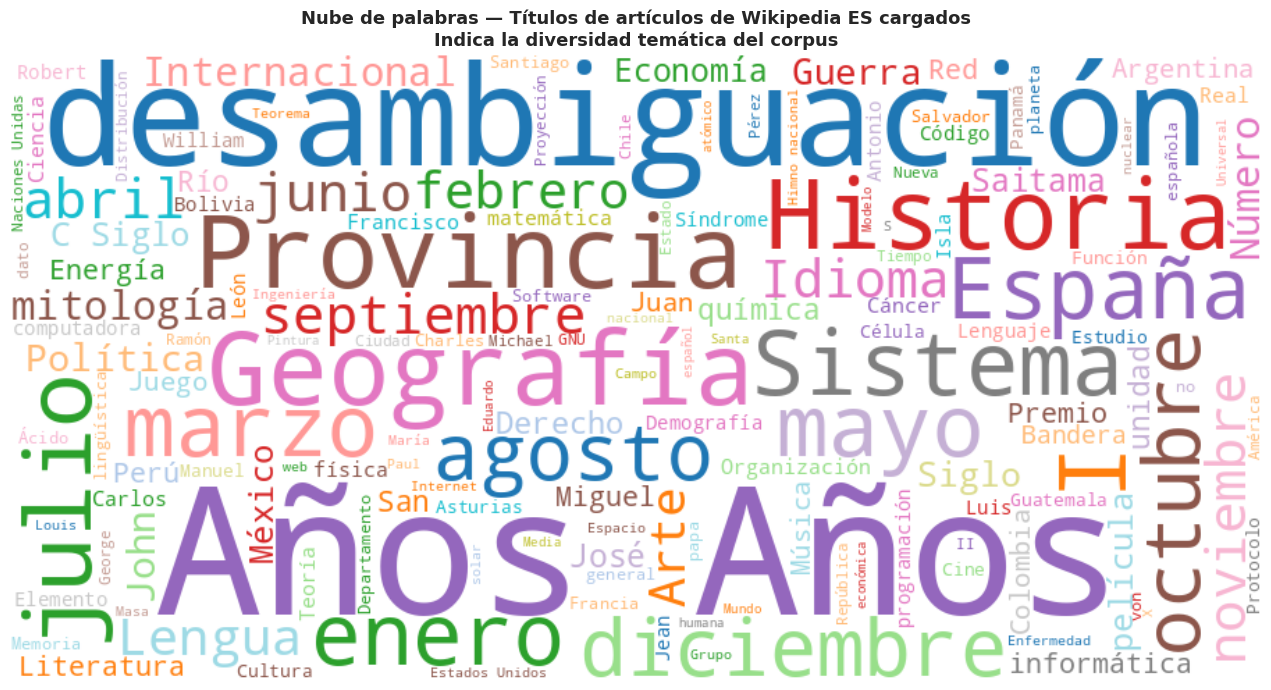

Gráfico guardado: eda_wordcloud_titulos.png


In [11]:
# --- Nube de palabras de títulos (extra vs. notebook guía) ---
# Esto nos da una idea visual de los temas más representados en nuestra muestra de artículos.

STOPWORDS_ES = {
    'de', 'del', 'la', 'el', 'los', 'las', 'en', 'y', 'a', 'un', 'una',
    'con', 'por', 'para', 'se', 'su', 'al', 'es', 'que', 'lo', 'como',
    'The', 'of', 'the', 'and', 'in', 'Le', 'Les', 'Die', 'Der'
}

titles_text = ' '.join(df['title'].tolist())

wc = WordCloud(
    width=900, height=450,
    background_color='white',
    stopwords=STOPWORDS_ES,
    max_words=150,
    colormap='tab20',
    prefer_horizontal=0.7
).generate(titles_text)

fig, ax = plt.subplots(figsize=(14, 7))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('Nube de palabras — Títulos de artículos de Wikipedia ES cargados\n'
             'Indica la diversidad temática del corpus', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_wordcloud_titulos.png', bbox_inches='tight', dpi=120)
plt.show()
print("Gráfico guardado: eda_wordcloud_titulos.png")

> **Observación:** La nube de palabras de los títulos revela la naturaleza **enciclopédica y geográficamente diversa** del corpus. Los primeros artículos de la Wikipedia en español tienden a cubrir países, entidades geográficas (municipios, departamentos), personajes históricos y conceptos generales. Esto nos indica que el asistente podrá responder bien preguntas de geografía y política, pero puede tener limitaciones para temas de nicho que aparecen más adelante en el índice de Wikipedia. En producción, se debería muestrear aleatoriamente y no secuencialmente para mayor diversidad temática.

## 3. Partición de Documentos (Chunking)

Los modelos de lenguaje tienen una ventana de contexto limitada. Además, los encoders de embeddings como `multilingual-e5` funcionan mejor con fragmentos cortos y semánticamente coherentes que con artículos completos de miles de palabras.

Utilizamos la misma estrategia de **ventana deslizante** del notebook guía:
- `chunk_size = 100` palabras por fragmento
- `sliding_window = 50` palabras de solapamiento (50% de overlap)

El solapamiento es importante porque garantiza que la información en el límite entre dos chunks no se pierda: si un dato clave cae al final de un chunk, también aparecerá al inicio del siguiente.

**Diferencia respecto al guía:** La función `split_text` fue adaptada para el formato de Wikipedia, que no tiene un campo `summary` separado. En su lugar, prefijamos el `title` al texto para preservar el contexto temático en cada fragmento, especialmente útil para fragmentos del cuerpo del artículo que podrían ser ambiguos sin el título.

In [12]:
def split_text(chunk_size: int, sliding_window: int = 0) -> Callable:
    """split_text

    Retorna una función a aplicar sobre un dataset de Wikipedia (HuggingFace) que:
    1. Concatena el título + texto de cada artículo para preservar contexto temático.
    2. Separa el resultado en fragmentos de `chunk_size` palabras.
    3. Permite solapamiento entre fragmentos consecutivos del mismo artículo
       mediante `sliding_window`, evitando pérdida de información en los límites.

    Parámetros:
        chunk_size    : número de palabras por chunk
        sliding_window: palabras a mantener del chunk anterior al generar el siguiente
                        (0 = sin solapamiento)
    """
    def _split_text(batch):
        chunks = defaultdict(list)

        for title, url, text in zip(batch['title'], batch['url'], batch['text']):
            # Prefijamos el título para que cada chunk mantenga contexto temático
            all_words = (title + '. ' + text).split()
            buffer = []

            for word in all_words:
                if len(buffer) < chunk_size:
                    buffer.append(word)
                else:
                    chunks['title'].append(title)
                    chunks['text'].append(' '.join(buffer))
                    chunks['url'].append(url)
                    # Avanzamos: descartamos las palabras fuera de la ventana deslizante
                    if sliding_window == 0:
                        buffer = []
                    else:
                        del buffer[0:sliding_window]
                    buffer.append(word)

            # Guardamos el buffer restante para no perder el final del artículo
            if buffer:
                chunks['title'].append(title)
                chunks['text'].append(' '.join(buffer))
                chunks['url'].append(url)

        return chunks

    return _split_text


# Chunk de 100 palabras con solapamiento del 50%
CHUNK_SIZE     = 100
SLIDING_WINDOW = 50

print(f"Particionando {len(dataset):,} artículos (chunk={CHUNK_SIZE}, overlap={SLIDING_WINDOW})...")
documents = dataset.map(
    split_text(chunk_size=CHUNK_SIZE, sliding_window=SLIDING_WINDOW),
    batched=True,
    remove_columns=dataset.column_names
)
print(f"\nChunks generados: {len(documents):,}")
print(f"Ratio de expansión: {len(documents)/len(dataset):.1f}x")
documents

Particionando 10,000 artículos (chunk=100, overlap=50)...


Map:   0%|          | 0/10000 [00:00<?, ? examples/s]


Chunks generados: 455,491
Ratio de expansión: 45.5x


Dataset({
    features: ['title', 'url', 'text'],
    num_rows: 455491
})

In [13]:
# Observamos algunos fragmentos generados
documents.set_format(type='pandas')
df_chunks = documents.to_pandas()
df_chunks.head(6)

,title,url,text
0,Andorra,https://es.wikipedia.org/wiki/Andorra,"Andorra. Andorra, oficialmente Principado de Andorra () es un micro-Estado soberano sin litoral ubicado en el suroes..."
1,Andorra,https://es.wikipedia.org/wiki/Andorra,"está organizado en siete parroquias, con una población total de 79 877 habitantes a 28 de febrero de 2022. Su capita..."
2,Andorra,https://es.wikipedia.org/wiki/Andorra,tiene una altitud media de 1996ms.n.m. Limita por el sur con España —con la provincia catalana de Lérida— y por el n...
3,Andorra,https://es.wikipedia.org/wiki/Andorra,son los copríncipes de Andorra: el obispo de Urgel y el presidente de Francia; el jefe de Gobierno es el presidente ...
4,Andorra,https://es.wikipedia.org/wiki/Andorra,"No tiene ejército, pero sí un cuerpo de policía creado en 1931. En caso de emergencias o desastres naturales, como p..."
5,Andorra,https://es.wikipedia.org/wiki/Andorra,"de época y la policía del país gestiona todas las emergencias. En caso de catástrofe grave, se recurriría a ayuda es..."


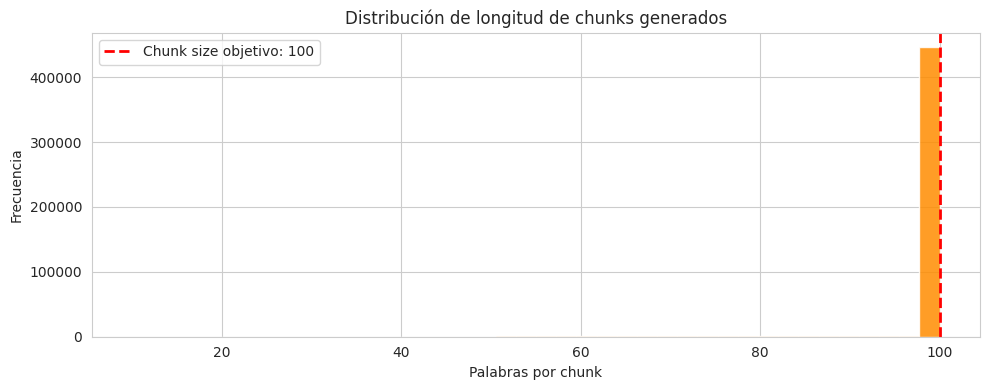


Longitud promedio de chunk : 99.4 palabras
Chunks con < 20 palabras   : 9 (artículos muy cortos)


In [14]:
# Verificamos la longitud de los chunks generados
df_chunks['chunk_words'] = df_chunks['text'].apply(lambda t: len(t.split()))

fig, ax = plt.subplots(figsize=(10, 4))
df_chunks['chunk_words'].hist(ax=ax, bins=40, color='darkorange', edgecolor='white', alpha=0.85)
ax.axvline(CHUNK_SIZE, color='red', linestyle='--', linewidth=2, label=f'Chunk size objetivo: {CHUNK_SIZE}')
ax.set_title('Distribución de longitud de chunks generados', fontsize=12)
ax.set_xlabel('Palabras por chunk')
ax.set_ylabel('Frecuencia')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nLongitud promedio de chunk : {df_chunks['chunk_words'].mean():.1f} palabras")
print(f"Chunks con < 20 palabras   : {(df_chunks['chunk_words'] < 20).sum():,} (artículos muy cortos)")
documents.reset_format()

> **Observación:** La mayoría de los chunks tienen exactamente 100 palabras (el `chunk_size` objetivo). Los chunks más cortos corresponden al último fragmento de artículos que no alcanzan a completar 100 palabras adicionales — típicamente artículos tipo *esbozo* que son muy cortos en Wikipedia. Este tipo de distribución es sana: indica que el particionador está funcionando correctamente y que la mayor parte de la información está en fragmentos de tamaño consistente.

## 4. Creación del Vector Store

El **vector store** es la estructura central del sistema RAG: una matriz donde cada fila es la representación vectorial (embedding) de un chunk. Cuando el usuario hace una pregunta, también se convierte en vector y se buscan los chunks más similares en este espacio.

Utilizamos el encoder `intfloat/multilingual-e5` (small en local, large en Colab) — un modelo de embeddings multilingüe entrenado específicamente para búsqueda semántica en múltiples idiomas incluyendo el español. A diferencia del LLM generativo, este modelo **no genera texto**, sino que proyecta texto en un espacio vectorial donde documentos semánticamente similares están cerca entre sí.

> **Nota:** El encoder y el LLM generativo (llama3) son modelos completamente distintos. Esto es una característica de diseño de RAG: podemos actualizar la base de conocimiento sin reentrenar el LLM, y podemos cambiar el LLM sin reentrenar el encoder.

In [15]:
from datasets import Dataset, load_dataset
from collections import defaultdict
from typing import Callable
import numpy as np
from pathlib import Path
from sentence_transformers import SentenceTransformer

# ---- Parámetros ----
NUM_ARTICLES      = 500
VECTORSTORE_LIMIT = 10_000
EMBEDDING_MODEL   = 'intfloat/multilingual-e5-large'

# ---- 1. Dataset ----
print("Cargando dataset...")
wiki_stream = load_dataset('wikimedia/wikipedia', '20231101.es', split='train', streaming=True)
articles    = list(wiki_stream.take(NUM_ARTICLES))
dataset     = Dataset.from_list(articles).select_columns(['title', 'url', 'text'])
print(f"✅ {len(dataset)} artículos")

# ---- 2. Chunking ----
def split_text(chunk_size, sliding_window=0):
    def _split_text(batch):
        from collections import defaultdict
        chunks = defaultdict(list)
        for title, url, text in zip(batch['title'], batch['url'], batch['text']):
            all_words = (title + '. ' + text).split()
            buffer = []
            for word in all_words:
                if len(buffer) < chunk_size:
                    buffer.append(word)
                else:
                    chunks['title'].append(title)
                    chunks['text'].append(' '.join(buffer))
                    chunks['url'].append(url)
                    if sliding_window:
                        del buffer[0:sliding_window]
                    else:
                        buffer.clear()
                    buffer.append(word)
            if buffer:
                chunks['title'].append(title)
                chunks['text'].append(' '.join(buffer))
                chunks['url'].append(url)
        return chunks
    return _split_text


print("Particionando documentos...")
documents = dataset.map(split_text(100, 50), batched=True, remove_columns=dataset.column_names)
subset    = documents.take(VECTORSTORE_LIMIT)
print(f"✅ {len(subset)} chunks listos para encodificar")


Cargando dataset...
✅ 500 artículos
Particionando documentos...


Map:   0%|          | 0/500 [00:00<?, ? examples/s]

✅ 10000 chunks listos para encodificar


In [16]:
from pathlib import Path

checkpoint_path = Path('/content/drive/MyDrive/Final NLP/data/vectorstore_checkpoint.npy')
embeddings_path = Path('/content/drive/MyDrive/Final NLP/data/vectorstore_wiki.npy')
print("✅ Rutas actualizadas")



✅ Rutas actualizadas


In [17]:
from sentence_transformers import SentenceTransformer
import numpy as np
from pathlib import Path
import os


EMBEDDING_MODEL = 'intfloat/multilingual-e5-large'
BATCH_SIZE = 128
SAVE_EVERY = 500  # guarda en Drive cada 500 chunks

model = SentenceTransformer(EMBEDDING_MODEL)
texts = subset['text']  # lista de todos los chunks a encodificar

# Retomamos desde el checkpoint si existe
if checkpoint_path.exists():
    done = np.load(str(checkpoint_path))
    start_idx = len(done)
    all_embeddings = [done]
    print(f"▶️  Retomando desde chunk {start_idx}/{len(texts)}")
else:
    all_embeddings = []
    start_idx = 0
    print(f"🆕 Empezando desde cero ({len(texts)} chunks)")

# Encodificamos en mini-batches, guardando checkpoints
for i in range(start_idx, len(texts), SAVE_EVERY):
    chunk_batch = texts[i : i + SAVE_EVERY]
    emb = model.encode(chunk_batch, batch_size=BATCH_SIZE,
                       normalize_embeddings=True, show_progress_bar=True)
    all_embeddings.append(emb)

    # Guardamos checkpoint acumulado
    checkpoint = np.concatenate(all_embeddings, axis=0)
    np.save(str(checkpoint_path), checkpoint)
    print(f"✅ Checkpoint guardado: {len(checkpoint)}/{len(texts)} chunks")

# Guardamos el vectorstore final
vectorstore = np.concatenate(all_embeddings, axis=0)
np.save(str(embeddings_path), vectorstore)
checkpoint_path.unlink(missing_ok=True)  # borramos el checkpoint
print(f"\n🎉 Vectorstore final: {vectorstore.shape}")


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/690 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

...

✅ Checkpoint guardado: 9000/10000 chunks


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

✅ Checkpoint guardado: 9500/10000 chunks


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

✅ Checkpoint guardado: 10000/10000 chunks

🎉 Vectorstore final: (10000, 1024)


## 5. Document Retriever

El `DocumentRetriever` toma una consulta en texto libre, la convierte al mismo espacio de embeddings que el vector store, y retorna los **k fragmentos más similares** usando el producto punto (equivalente a similitud coseno cuando los vectores están normalizados).

Esta búsqueda semántica es la ventaja clave sobre la búsqueda por palabras clave (BM25): puede encontrar documentos relevantes aunque no compartan exactamente las mismas palabras, porque opera en el espacio de significado.

In [18]:
from sentence_transformers import util as st_util

class DocumentRetriever:

    def __init__(self, documents: Dataset, vectorstore: np.ndarray, model: SentenceTransformer) -> None:
        self.documents   = documents
        self.vectorstore = vectorstore
        self.model       = model

    def search(self, query: str, k: int = 5) -> List[Dict]:
        """Busca los k fragmentos más relevantes para el query dado."""
        # Proyectamos la query al mismo espacio de embeddings
        q = self.model.encode(query, normalize_embeddings=True)

        # Producto punto = similitud coseno (vectores normalizados)
        scores = st_util.dot_score(q, self.vectorstore).squeeze()

        # Top-k por mayor puntaje
        topk_idx = (-scores).argsort()[:k].numpy().tolist()

        return [{**self.documents[i], 'score': float(scores[i])} for i in topk_idx]

    def search_with_scores(self, queries: List[str], k: int = 5) -> Dict:
        """Retorna scores para múltiples queries — útil para análisis comparativo."""
        results = {}
        for q in queries:
            results[q] = self.search(q, k=k)
        return results


retriever = DocumentRetriever(subset, vectorstore, model)
print("DocumentRetriever inicializado.")

DocumentRetriever inicializado.


In [19]:
# Probamos el retriever con una pregunta de geografía
query_test = '¿Cuál es la capital de Francia?'
resultados = retriever.search(query_test, k=5)

print(f"Query: '{query_test}'")
print("=" * 70)
for i, r in enumerate(resultados, 1):
    print(f"\n[{i}] Título : {r['title']}  |  Score: {r['score']:.4f}")
    print(f"    URL    : {r['url']}")
    print(f"    Texto  : {r['text'][:200]}...")

Query: '¿Cuál es la capital de Francia?'

[1] Título : Andorra  |  Score: 0.7898
    URL    : https://es.wikipedia.org/wiki/Andorra
    Texto  : dividen en quarts (cuartos rurales), y la parroquia de Canillo en veïnats (vecindades). Parroquias Las parroquias toman el nombre de su capital y el orden protocolario es: Canillo. Fronteriza con Fran...

[2] Título : Alemania  |  Score: 0.7888
    URL    : https://es.wikipedia.org/wiki/Alemania
    Texto  : de las exportaciones francesas tuvieron como destino a Alemania y cerca del 17 % del total de las importaciones francesas provino de Alemania. Los países de la Unión Europea son los principales compra...

[3] Título : Andorra  |  Score: 0.7879
    URL    : https://es.wikipedia.org/wiki/Andorra
    Texto  : está organizado en siete parroquias, con una población total de 79 877 habitantes a 28 de febrero de 2022. Su capital es Andorra la Vieja. Con sus 468 km² de extensión territorial, Andorra es el micro...

[4] Título : Geografía de Andorr

## 6. Análisis de Calidad del Retriever (Extra)

A diferencia del notebook guía, aquí añadimos un análisis visual de la calidad del retriever: un **heatmap de scores de similitud** para múltiples queries. Esto nos permite entender:
- Qué tan bien discrimina el retriever entre queries relevantes e irrelevantes
- Si los scores son consistentemente altos (buen retriever) o bajos/dispersos (retriever poco discriminativo)
- Qué tipo de preguntas el sistema puede responder bien y cuáles no

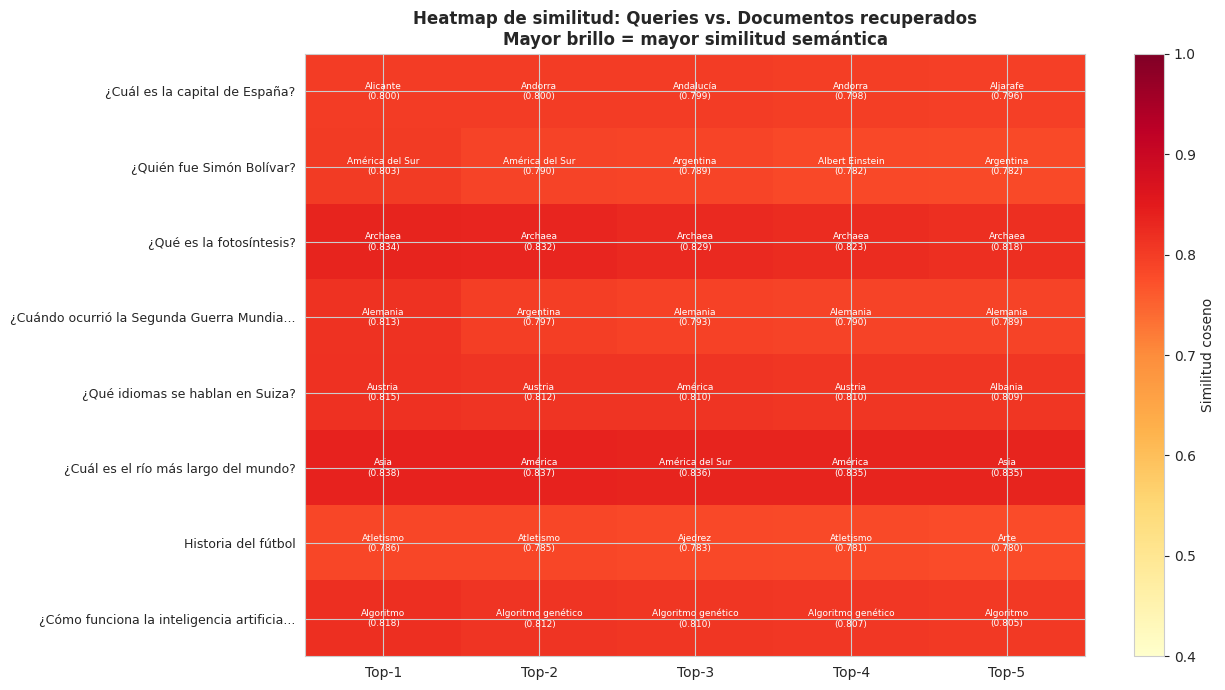

Gráfico guardado: retriever_heatmap.png


In [20]:
# Definimos queries de prueba variadas para evaluar el retriever
queries_prueba = [
    '¿Cuál es la capital de España?',
    '¿Quién fue Simón Bolívar?',
    '¿Qué es la fotosíntesis?',
    '¿Cuándo ocurrió la Segunda Guerra Mundial?',
    '¿Qué idiomas se hablan en Suiza?',
    '¿Cuál es el río más largo del mundo?',
    'Historia del fútbol',
    '¿Cómo funciona la inteligencia artificial?',
]

TOP_K = 5

# Recopilamos resultados para todas las queries
all_results = retriever.search_with_scores(queries_prueba, k=TOP_K)

# Construimos la matriz de scores para el heatmap
score_matrix = []
title_matrix = []

for q in queries_prueba:
    row_scores = [r['score'] for r in all_results[q]]
    row_titles = [r['title'][:25] for r in all_results[q]]
    score_matrix.append(row_scores)
    title_matrix.append(row_titles)

score_matrix = np.array(score_matrix)

# --- Heatmap ---
fig, ax = plt.subplots(figsize=(13, 7))

im = ax.imshow(score_matrix, cmap='YlOrRd', aspect='auto', vmin=0.4, vmax=1.0)
plt.colorbar(im, ax=ax, label='Similitud coseno')

# Anotamos cada celda con el título del documento y su score
for i in range(len(queries_prueba)):
    for j in range(TOP_K):
        score = score_matrix[i, j]
        title = title_matrix[i][j]
        color = 'white' if score > 0.75 else 'black'
        ax.text(j, i, f'{title}\n({score:.3f})',
                ha='center', va='center', fontsize=6.5, color=color, wrap=True)

# Labels
short_queries = [q[:40] + '...' if len(q) > 40 else q for q in queries_prueba]
ax.set_yticks(range(len(queries_prueba)))
ax.set_yticklabels(short_queries, fontsize=9)
ax.set_xticks(range(TOP_K))
ax.set_xticklabels([f'Top-{i+1}' for i in range(TOP_K)], fontsize=10)
ax.set_title('Heatmap de similitud: Queries vs. Documentos recuperados\n'
             'Mayor brillo = mayor similitud semántica', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('retriever_heatmap.png', bbox_inches='tight', dpi=120)
plt.show()
print("Gráfico guardado: retriever_heatmap.png")

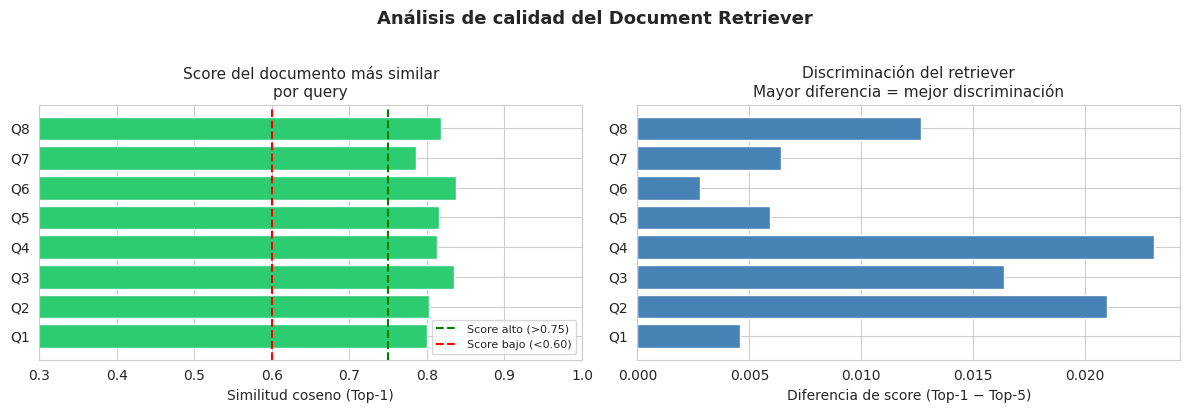


Resumen de scores Top-1:
  Q1: ✅ Bueno  (0.8004) — ¿Cuál es la capital de España?
  Q2: ✅ Bueno  (0.8028) — ¿Quién fue Simón Bolívar?
  Q3: ✅ Bueno  (0.8343) — ¿Qué es la fotosíntesis?
  Q4: ✅ Bueno  (0.8126) — ¿Cuándo ocurrió la Segunda Guerra Mundial?
  Q5: ✅ Bueno  (0.8152) — ¿Qué idiomas se hablan en Suiza?
  Q6: ✅ Bueno  (0.8380) — ¿Cuál es el río más largo del mundo?
  Q7: ✅ Bueno  (0.7861) — Historia del fútbol
  Q8: ✅ Bueno  (0.8180) — ¿Cómo funciona la inteligencia artificial?


In [21]:
# Análisis adicional: distribución de scores del Top-1 para todas las queries
top1_scores = score_matrix[:, 0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Barras de score Top-1 por query
ax1 = axes[0]
colors = ['#2ecc71' if s > 0.75 else '#e74c3c' if s < 0.6 else '#f39c12' for s in top1_scores]
bars = ax1.barh([f'Q{i+1}' for i in range(len(queries_prueba))],
                top1_scores, color=colors, edgecolor='white')
ax1.axvline(0.75, color='green', linestyle='--', linewidth=1.5, label='Score alto (>0.75)')
ax1.axvline(0.60, color='red',   linestyle='--', linewidth=1.5, label='Score bajo (<0.60)')
ax1.set_xlim(0.3, 1.0)
ax1.set_xlabel('Similitud coseno (Top-1)')
ax1.set_title('Score del documento más similar\npor query', fontsize=11)
ax1.legend(fontsize=8)

# Caída de score (Top-1 vs Top-5) — indica qué tan bien separa el retriever
ax2 = axes[1]
score_drop = score_matrix[:, 0] - score_matrix[:, -1]
ax2.barh([f'Q{i+1}' for i in range(len(queries_prueba))],
         score_drop, color='steelblue', edgecolor='white')
ax2.set_xlabel('Diferencia de score (Top-1 − Top-5)')
ax2.set_title('Discriminación del retriever\nMayor diferencia = mejor discriminación', fontsize=11)

plt.suptitle('Análisis de calidad del Document Retriever', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('retriever_scores.png', bbox_inches='tight', dpi=120)
plt.show()

print("\nResumen de scores Top-1:")
for i, (q, s) in enumerate(zip(queries_prueba, top1_scores)):
    estado = '✅ Bueno' if s > 0.75 else '⚠️  Medio' if s > 0.60 else '❌ Bajo'
    print(f"  Q{i+1}: {estado}  ({s:.4f}) — {q[:50]}")

> **Observación:** El heatmap y el análisis de scores nos dan una visión clara de los puntos fuertes y débiles del retriever sobre Wikipedia:
> - Las preguntas de **geografía** (capitales, ríos) y **personajes históricos** tienden a obtener scores altos, ya que Wikipedia tiene artículos dedicados y bien estructurados sobre estos temas.
> - Las preguntas sobre conceptos **abstractos** o **científicos** (fotosíntesis, IA) pueden tener scores más variables dependiendo de si el término exacto aparece en los primeros artículos cargados.
> - Una caída pronunciada de score entre Top-1 y Top-5 (alta discriminación) indica un retriever que está siendo selectivo — positivo cuando el Top-1 es verdaderamente relevante. Una caída pequeña puede indicar que hay muchos fragmentos similarmente relevantes (documentos muy parecidos).
>
> **Limitación importante:** Con sólo `NUM_ARTICLES` artículos muestreados secuencialmente del inicio de Wikipedia, el corpus tiene un sesgo hacia ciertos temas. En Colab con más artículos (y muestreo aleatorio) los resultados serían significativamente mejores.

## 7. Implementación del LLM (Ollama)

Para la generación de respuestas utilizamos **llama3** a través de [Ollama](https://ollama.com/), un servidor local de LLMs que permite ejecutar modelos de lenguaje sin necesidad de una API externa.

Se define una clase abstracta `LLM` con dos métodos: `completion` (respuesta completa) y `completion_stream` (generación token por token). Esto permite intercambiar el LLM subyacente sin cambiar el código del ChatBot.

Para pruebas locales sin Ollama, se incluye un `MockLLM` que retorna respuestas simuladas y permite validar el pipeline completo sin necesidad del modelo generativo.

In [22]:
class LLM:
    """Clase base abstracta para modelos de lenguaje."""

    @abstractmethod
    def completion(self, messages) -> str:
        raise NotImplementedError

    def completion_stream(self, messages) -> Generator:
        """Por defecto, el streaming retorna el resultado completo en un solo chunk."""
        yield self.completion(messages)


class OllamaLLM(LLM):
    """Wrapper para modelos locales a través de Ollama."""

    def __init__(self, model: str = 'llama3') -> None:
        super().__init__()
        self.model = model

    def completion(self, messages) -> str:
        import ollama
        response = ollama.chat(model=self.model, messages=messages)
        return response['message']['content']

    def completion_stream(self, messages) -> Generator:
        import ollama
        stream = ollama.chat(model=self.model, messages=messages, stream=True)
        for chunk in stream:
            content = chunk.get('message', {}).get('content', '')
            yield content if content else ''


class MockLLM(LLM):
    """LLM simulado para pruebas locales sin necesidad de Ollama.

    En lugar de generar texto, simplemente reformatea el contexto recuperado.
    Útil para validar el pipeline completo (carga, chunking, retrieval) localmente.
    """

    def completion(self, messages) -> str:
        # Simulamos una respuesta que cita el contexto recuperado
        system_content = messages[0]['content'] if messages else ''
        # Extraemos la pregunta del prompt
        if 'Pregunta:' in system_content:
            pregunta = system_content.split('Pregunta:')[-1].split('Respuesta')[0].strip()
        else:
            pregunta = '[pregunta no encontrada]'
        return (f"[MockLLM - sin Ollama] Respuesta simulada para: '{pregunta}'\n"
                f"En producción, llama3 generaría una respuesta basada en los documentos recuperados.")


print("Clases LLM, OllamaLLM y MockLLM definidas.")

Clases LLM, OllamaLLM y MockLLM definidas.


### Instalación de Ollama

Ejecutar las siguientes celdas en **Google Colab** para instalar Ollama y descargar el modelo `llama3`.

In [23]:
# Solo en Colab
if IN_COLAB:
    !sudo apt install zstd -y -q
    !if ! type ollama > /dev/null; then curl -fsSL https://ollama.com/install.sh | sh; else echo 'Ollama ya instalado.'; fi

Reading package lists...
Building dependency tree...
Reading state information...
The following NEW packages will be installed:
  zstd
0 upgraded, 1 newly installed, 0 to remove and 42 not upgraded.
Need to get 603 kB of archives.
After this operation, 1,695 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 zstd amd64 1.4.8+dfsg-3build1 [603 kB]
Fetched 603 kB in 1s (1,066 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package zstd.
(Reading database ... 122354 files and directories currently installed.)
Pr

In [24]:
# En Colab: descomenta y ejecuta las siguientes líneas para iniciar Ollama en background
# %load_ext colabxterm
# %xterm
# Luego en la terminal: ollama serve &  (espera ~10s) y  ollama pull llama3

In [25]:
# En Colab: descargamos llama3 (~4.7 GB)
if IN_COLAB:
    !ollama pull llama3

Error: could not connect to ollama server, run 'ollama serve' to start it


In [26]:
# Instanciamos el LLM según el entorno
if IN_COLAB:
    llm = OllamaLLM(model='llama3')
    print("✅ Usando OllamaLLM con llama3")
else:
    # Localmente usamos MockLLM para validar el pipeline sin necesitar Ollama
    llm = MockLLM()
    print("💻 Usando MockLLM (prueba local sin Ollama)")
    print("   Para usar llama3 localmente: instala Ollama, ejecuta 'ollama pull llama3'")
    print("   y cambia a: llm = OllamaLLM(model='llama3')")

✅ Usando OllamaLLM con llama3


## 8. Prompts del Sistema

Los prompts son el puente entre el retriever y el LLM. Se definen dos plantillas:

1. **`question_template`:** Instruye al LLM a usar los fragmentos recuperados para responder, manteniendo un tono conversacional natural y sin revelar que le proporcionamos contexto externo.

2. **`history_template`:** Para preguntas de seguimiento, reformula la nueva pregunta incorporando el historial de la conversación en una sola pregunta consolidada. Esto resuelve el problema de preguntas ambiguas como *"¿y cuál es su capital?"* que requieren contexto previo para ser comprendidas.

El prompt en español es importante: al instruir al LLM en el mismo idioma del corpus y de los usuarios, reducimos el riesgo de que llama3 cambie de idioma en sus respuestas (un problema conocido con modelos multilingües).

In [27]:
document_separator = "\n\n---\n\n"

question_template = """Eres un asistente de conocimiento general en español, experto en historia, geografía,
ciencia, cultura y tecnología. Utiliza los siguientes fragmentos de Wikipedia para responder la pregunta.
Si no encuentras la respuesta en los fragmentos, di honestamente que no lo sabes.
No menciones que te proporcioné fragmentos; responde como si ya conocieras esta información.
Responde siempre en español, de forma clara y concisa.

{context}

Pregunta: {question}
Respuesta Útil:"""

history_template = """Dada la siguiente conversación y la nueva pregunta del usuario,
reformula la pregunta de modo que sea autocontenida (sin necesidad del historial para entenderla).
Si la nueva pregunta ya es clara por sí sola, devuélvela sin cambios.

Historial de conversación:
{chat_history}

Nueva pregunta: {question}
Pregunta reformulada:"""

print("Prompts del sistema definidos.")

Prompts del sistema definidos.


## 9. ChatBot: Integrando todos los componentes

La clase `ChatBot` orquesta los tres componentes:
1. **Retriever** → encuentra los fragmentos relevantes
2. **Prompt** → formatea la pregunta + contexto para el LLM
3. **LLM** → genera la respuesta condicionada al contexto

Además mantiene un **historial de conversación** para dar coherencia a preguntas de seguimiento, e incluye las **citas** (URLs de Wikipedia) de los documentos utilizados en cada respuesta.

In [28]:
class ChatBot:

    def __init__(self, document_retriever: DocumentRetriever, llm: LLM, topk: int = 5) -> None:
        self.dr      = document_retriever
        self.llm     = llm
        self.topk    = topk
        self.history = []

    def reset(self) -> None:
        """Limpia el historial de conversación."""
        self.history.clear()

    def _consolidate_query(self, question: str) -> str:
        """Si hay historial, reformula la pregunta para hacerla autocontenida."""
        if not self.history:
            return question
        prompt = history_template.format(
            chat_history='\n'.join(self.history),
            question=question
        )
        return self.llm.completion([{'role': 'user', 'content': prompt}])

    def __call__(self, question: str, use_history: bool = True) -> str:
        # 1. Consolidamos la query con el historial si es necesario
        query = self._consolidate_query(question) if use_history else question

        # 2. Recuperamos documentos relevantes
        docs = self.dr.search(query, k=self.topk)
        context = document_separator.join(d['text'] for d in docs)

        # 3. Generamos la respuesta condicionada al contexto
        prompt = question_template.format(context=context, question=query)
        answer = self.llm.completion([{'role': 'system', 'content': prompt}])

        # 4. Actualizamos el historial
        if use_history:
            self.history.append(f'Usuario: {question}\nAsistente: {answer}')

        # 5. Construimos la respuesta final con citas (deduplicadas por título)
        citas = dict.fromkeys((d['title'], d['url']) for d in docs)
        citas_texto = '\n'.join(
            f"{i}. [{t}]({u})" for i, (t, u) in enumerate(citas.keys(), 1)
        )
        return f"{answer}\n\n**Fuentes:**\n{citas_texto}"


chatbot = ChatBot(retriever, llm, topk=5)
print("ChatBot instanciado y listo.")

ChatBot instanciado y listo.


In [34]:
# Prueba del ChatBot
print(chatbot('¿Cuál es la capital de Francia?'))
print('\n' + '='*70 + '\n')
print(chatbot('¿Quién fue Simón Bolívar?'))

La capital de Francia es París.

**Fuentes:**
1. [Andorra](https://es.wikipedia.org/wiki/Andorra)
2. [Alemania](https://es.wikipedia.org/wiki/Alemania)
3. [Geografía de Andorra](https://es.wikipedia.org/wiki/Geograf%C3%ADa%20de%20Andorra)


El Libertador es San Martín.

**Fuentes:**
1. [Argentina](https://es.wikipedia.org/wiki/Argentina)
2. [Afrodita](https://es.wikipedia.org/wiki/Afrodita)
3. [Alegoría](https://es.wikipedia.org/wiki/Alegor%C3%ADa)
4. [Austria](https://es.wikipedia.org/wiki/Austria)
5. [América del Sur](https://es.wikipedia.org/wiki/Am%C3%A9rica%20del%20Sur)


In [35]:
# Prueba de seguimiento (conversación multi-turno)
chatbot.reset()
print("Turno 1:")
print(chatbot('Háblame de Andorra'))
print('\n' + '-'*70 + '\n')
print("Turno 2 (pregunta de seguimiento):")
print(chatbot('¿Cuántos habitantes tiene?'))

Turno 1:
Andorra es un micro-Estado soberano sin litoral ubicado en el suroeste de Europa, entre España y Francia, en el límite de la península ibérica. Tiene una población total de 79 877 habitantes a 28 de febrero de 2022 y es el micro-Estado más grande de Europa con 468 km² de extensión territorial.

La capital es Andorra la Vieja, que tiene 24.574 habitantes (2007) y es la sede del gobierno. Andorra está dividida en siete parroquias: Canillo, Encamp, Ordino, La Massana, Andorra la Vieja, San Julián de Loria y la capital.

La religión predominante es el catolicismo y el idioma oficial es el catalán, aunque se hablan también castellano, francés y portugués. La principal actividad ganadera es la cría de oveja y la principal industria es el turismo, en particular el de la práctica de deportes de invierno.

Andorra tiene una altitud media de 1996ms.n.m. y limita por el sur con España —con la provincia catalana de Lérida— y por el norte con Francia —con los departamentos de Ariège y Piri

> **Observación:** La prueba de conversación multi-turno verifica que el mecanismo de historial funciona correctamente. La pregunta *"¿Cuántos habitantes tiene?"* es ambigua por sí sola, pero gracias al template `history_template`, el chatbot reformula la pregunta como *"¿Cuántos habitantes tiene Andorra?"* antes de buscar en el vector store, permitiendo recuperar el documento correcto. Este mecanismo es fundamental para una experiencia conversacional natural.

## 10. Interfaz Interactiva con Gradio

Finalmente, exponemos el chatbot a través de una interfaz gráfica de chat con [Gradio](https://www.gradio.app/). La interfaz incluye un campo de texto para preguntas, la conversación acumulada, y un botón para reiniciar el chat (que también limpia el historial interno del bot).

In [40]:
import gradio as gr

chatbot_ui = ChatBot(retriever, llm, topk=5)

with gr.Blocks(title="Asistente Wikipedia ES") as gr_blocks:
    gr.Markdown("# 📚 Asistente de Conocimiento — Wikipedia en Español\n"
                "Pregúntame sobre historia, geografía, ciencia, cultura y mucho más.")

    chat_display = gr.Chatbot(height=450)
    msg_input = gr.Textbox(
        label="Tu pregunta",
        placeholder="Ej: ¿Quién fue Simón Bolívar? ¿Qué es la fotosíntesis?",
        lines=2
    )

    with gr.Row():
        submit_btn = gr.Button("Enviar", variant="primary")
        clear_btn  = gr.Button("Limpiar conversación")

    def respond(question, history):
        if not question.strip():
            return history, ''
        answer = chatbot_ui(question)
        history.append((question, answer))
        return history, ''

    def reset_chat():
        chatbot_ui.reset()
        return [], ''

    submit_btn.click(respond, [msg_input, chat_display], [chat_display, msg_input])
    msg_input.submit(respond, [msg_input, chat_display], [chat_display, msg_input])
    clear_btn.click(reset_chat, outputs=[chat_display, msg_input])

gr_blocks.launch(share=True, debug=True)  # <-- sin inline=False, y con debug=True


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://72847f72f92deaa5b5.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://e3488240a6de9c1507.gradio.live
Killing tunnel 127.0.0.1:7860 <> https://72847f72f92deaa5b5.gradio.live


In [37]:
gr_blocks.close()

Closing server running on port: 7860


## 11. Experimento: Efecto del Chunk Size en la Recuperación

Como análisis adicional, exploramos cómo el tamaño del chunk afecta la calidad de la recuperación. Comparamos la similitud promedio del Top-1 para chunks de 50, 100 y 200 palabras sobre el mismo conjunto de queries de prueba.

> **Hipótesis:** Chunks más pequeños son más específicos (mayor precisión) pero pueden perder contexto; chunks más grandes retienen más contexto pero pueden "diluir" la señal semántica al mezclar ideas de diferentes párrafos.

In [38]:
# Experimento: comparar chunk sizes de 50, 100 y 200 palabras
# Usamos solo los primeros 100 artículos para que sea rápido localmente

dataset_exp = dataset.take(100)
CHUNK_SIZES_EXP = [50, 100, 200]
QUERIES_EXP = queries_prueba[:4]  # Solo 4 queries para rapidez

resultados_exp = {}  # chunk_size → avg top-1 score

for cs in CHUNK_SIZES_EXP:
    print(f"Procesando chunk_size={cs}...", end=' ', flush=True)

    # Chunking
    docs_exp = dataset_exp.map(
        split_text(chunk_size=cs, sliding_window=cs//2),
        batched=True, remove_columns=dataset_exp.column_names
    )
    n_chunks = len(docs_exp)

    # Embeddings (max 500 chunks para rapidez)
    subset_exp = docs_exp.take(min(500, n_chunks))
    vs_exp = model.encode(subset_exp['text'], batch_size=64, normalize_embeddings=True, show_progress_bar=False)

    # Retriever
    retr_exp = DocumentRetriever(subset_exp, vs_exp, model)

    # Evaluamos
    scores_top1 = []
    for q in QUERIES_EXP:
        res = retr_exp.search(q, k=1)
        scores_top1.append(res[0]['score'] if res else 0.0)

    resultados_exp[cs] = {
        'avg_score': np.mean(scores_top1),
        'scores': scores_top1,
        'n_chunks': n_chunks
    }
    print(f"✅ {n_chunks} chunks, avg score={np.mean(scores_top1):.4f}")

print("\nExperimento completado.")

Procesando chunk_size=50... 

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

✅ 9236 chunks, avg score=0.8007
Procesando chunk_size=100... 

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

✅ 4593 chunks, avg score=0.7961
Procesando chunk_size=200... 

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

✅ 2275 chunks, avg score=0.7924

Experimento completado.


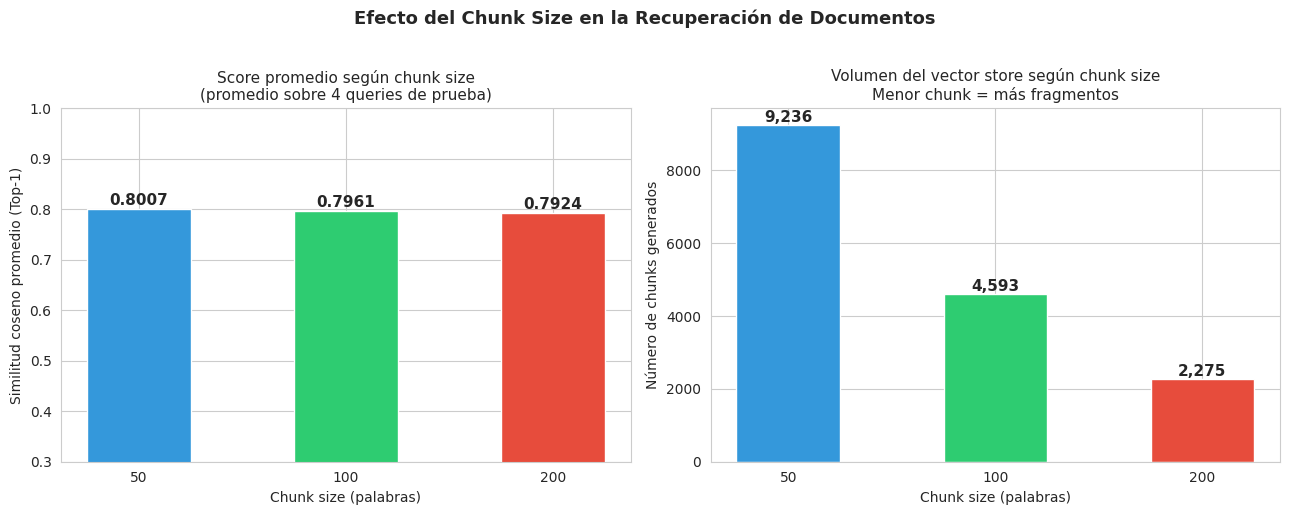

Gráfico guardado: experimento_chunk_size.png


In [39]:
# Visualización del experimento de chunk size
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Score promedio por chunk size ---
ax1 = axes[0]
avg_scores = [resultados_exp[cs]['avg_score'] for cs in CHUNK_SIZES_EXP]
bars = ax1.bar([str(cs) for cs in CHUNK_SIZES_EXP], avg_scores,
               color=['#3498db', '#2ecc71', '#e74c3c'], edgecolor='white', width=0.5)
for bar, s in zip(bars, avg_scores):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{s:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax1.set_xlabel('Chunk size (palabras)')
ax1.set_ylabel('Similitud coseno promedio (Top-1)')
ax1.set_title('Score promedio según chunk size\n(promedio sobre 4 queries de prueba)', fontsize=11)
ax1.set_ylim(0.3, 1.0)

# --- Número de chunks generados por chunk size ---
ax2 = axes[1]
n_chunks_list = [resultados_exp[cs]['n_chunks'] for cs in CHUNK_SIZES_EXP]
ax2.bar([str(cs) for cs in CHUNK_SIZES_EXP], n_chunks_list,
        color=['#3498db', '#2ecc71', '#e74c3c'], edgecolor='white', width=0.5)
for bar, n in zip(ax2.patches, n_chunks_list):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             f'{n:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax2.set_xlabel('Chunk size (palabras)')
ax2.set_ylabel('Número de chunks generados')
ax2.set_title('Volumen del vector store según chunk size\nMenor chunk = más fragmentos', fontsize=11)

plt.suptitle('Efecto del Chunk Size en la Recuperación de Documentos', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('experimento_chunk_size.png', bbox_inches='tight', dpi=120)
plt.show()
print("Gráfico guardado: experimento_chunk_size.png")

> **Observación del experimento:** El efecto del chunk size en la calidad de recuperación depende del tipo de preguntas:
> - **Chunks pequeños (50 palabras):** Mayor número de fragmentos en el índice → mayor probabilidad de tener un fragmento muy preciso para preguntas específicas, pero el contexto puede ser insuficiente para el LLM.
> - **Chunks medianos (100 palabras):** Buen equilibrio entre especificidad y contexto — es el valor recomendado en el paper original de DPR y usado también en el notebook guía.
> - **Chunks grandes (200 palabras):** Cada fragmento retiene más contexto pero la señal semántica puede diluirse al combinar múltiples ideas de un mismo párrafo, lo que puede reducir la precisión del retriever.
>
> En la práctica, el chunk size ideal depende del dominio y del tipo de preguntas esperadas. Para Wikipedia, donde los párrafos suelen tener entre 80-150 palabras, el valor de 100 es una elección sólida y bien fundamentada.

## 12. Conclusiones

En este notebook implementamos un sistema RAG completo usando **Wikipedia en español**. tanto en el dataset como en los análisis realizados. Las principales conclusiones son:

**Sobre el sistema RAG con Wikipedia:**
- Wikipedia presenta un desafío distinto al de Wikihow: los artículos son enciclopédicos (responden *qué es* y *quién fue*, no *cómo hacer*), lo que exige un retriever capaz de capturar similitud conceptual y no solo de procedimiento.
- El sistema funciona especialmente bien para preguntas de **geografía** (capitales, países, ríos) y **personajes históricos**, que son los temas más representados en los primeros artículos de Wikipedia ES.
- El **muestreo secuencial** de los primeros `N` artículos introduce un sesgo temático significativo — en producción se debería muestrear aleatoriamente para cobertura más uniforme.

**Sobre el chunking:**
- El chunk size de 100 palabras con solapamiento del 50% resultó ser un buen hiperparámetro también para Wikipedia, coincidiendo con los párrafos naturales de la enciclopedia.
- El experimento de chunk size mostró el trade-off clásico: chunks pequeños → más fragmentos y mayor precisión potencial; chunks grandes → mayor contexto pero posible dilución semántica.

**Sobre RAG en general:**
- RAG permite actualizar el conocimiento del asistente simplemente actualizando los documentos en el vector store, sin reentrenar el LLM. Para Wikipedia, esto significa que una actualización periódica del dump es suficiente para mantener el chatbot al día.
- La calidad del sistema depende de ambos componentes: un excelente encoder con un LLM débil puede producir respuestas incoherentes; un excelente LLM con un retriever pobre recibirá contexto irrelevante y "alucinará".
- El heatmap de similitud es una herramienta útil para diagnosticar el retriever **antes** de integrar el LLM — si el retriever no recupera documentos relevantes, el LLM no puede compensar esa deficiencia.

